In [1]:
# pandas → CMP 데이터를 표 형태로 관리
# numpy → 실습용 CMP 측정값 생성
# matplotlib → CMP 파라미터 관계 시각화

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 실제 cmp_data.csv가 없으므로 실습용 가상 CMP 데이터 생성
# 실행할 때마다 같은 결과가 나오도록 난수 고정

np.random.seed(42)

# CMP 공정 횟수
n = 150

# CMP 설비 3대를 사용한다고 가정
tool_id = np.random.choice(
    ['CMP_A', 'CMP_B', 'CMP_C'],
    size=n
)

# Pad가 처리한 누적 웨이퍼 수
pad_life = np.random.randint(
    1, 1001,
    size=n
)

# Removal Rate 생성
# Pad 수명이 증가하면서 RR이 조금 감소한다고 가정
rr_mean = (
    3000
    - 0.35 * pad_life
    + np.random.normal(0, 100, n)
)

# Within-Wafer Non-Uniformity 생성
# Pad 수명이 증가하면서 균일도가 조금 나빠진다고 가정
wiwnu = (
    2
    + 0.002 * pad_life
    + np.random.normal(0, 0.4, n)
)

# Dishing 생성
# WIWNU가 증가하면 Dishing도 어느 정도 증가한다고 가정
dishing = (
    10
    + 3 * wiwnu
    + np.random.normal(0, 3, n)
)

# DataFrame 생성
df = pd.DataFrame({
    'RUN_ID': range(1, n + 1),
    'TOOL_ID': tool_id,
    'PAD_LIFE_WAFER': pad_life,
    'RR_MEAN': rr_mean,
    'WIWNU': wiwnu,
    'DISHING_NM': dishing
})

# 데이터 확인
df.head()

,RUN_ID,TOOL_ID,PAD_LIFE_WAFER,RR_MEAN,WIWNU,DISHING_NM
0,1,CMP_C,96,2927.573560,1.943105,18.071419
1,2,CMP_A,900,2596.448763,3.657805,20.101337
2,3,CMP_C,734,2707.425497,3.848804,27.711691
3,4,CMP_C,485,2885.862180,3.551020,19.694980
4,5,CMP_A,407,2961.936061,2.958806,17.536366


In [3]:
# 데이터 행/열 개수 확인
print("데이터 크기:", df.shape)

# CMP 데이터 컬럼 확인
print("컬럼:")
print(df.columns.tolist())

# 각 변수의 기본 통계량 확인
df.describe()

데이터 크기: (150, 6)
컬럼:
['RUN_ID', 'TOOL_ID', 'PAD_LIFE_WAFER', 'RR_MEAN', 'WIWNU', 'DISHING_NM']


,RUN_ID,PAD_LIFE_WAFER,RR_MEAN,WIWNU,DISHING_NM
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,522.373333,2836.037693,3.096268,19.095549
std,43.445368,268.990545,134.592883,0.685396,3.798999
min,1.000000,2.000000,2528.308027,1.356931,8.855896
25%,38.250000,285.750000,2734.099061,2.578823,16.816043
50%,75.500000,546.000000,2833.910203,3.157569,19.175001
75%,112.750000,733.000000,2938.627901,3.603191,21.382766
max,150.000000,997.000000,3194.692216,4.584505,28.553355


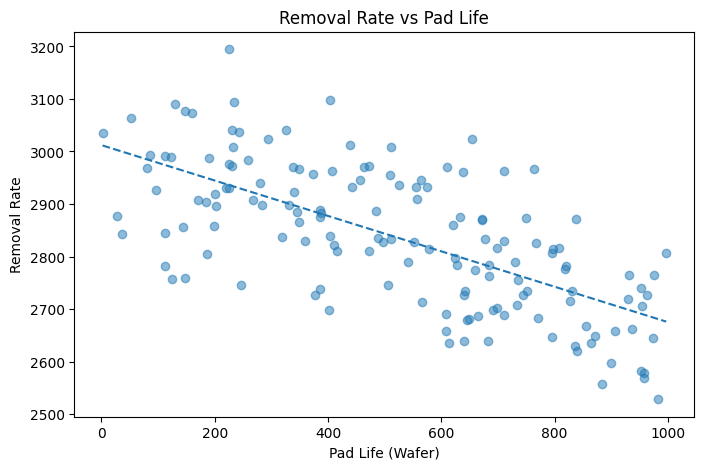

In [4]:
# Pad가 많은 웨이퍼를 처리할수록
# Removal Rate가 어떻게 변하는지 확인

plt.figure(figsize=(8, 5))

plt.scatter(
    df['PAD_LIFE_WAFER'],
    df['RR_MEAN'],
    alpha=0.5
)

# 1차 회귀선 계산
z = np.polyfit(
    df['PAD_LIFE_WAFER'],
    df['RR_MEAN'],
    1
)

p = np.poly1d(z)

# x값을 정렬하여 회귀선을 자연스럽게 표시
x_sorted = np.sort(df['PAD_LIFE_WAFER'])

plt.plot(
    x_sorted,
    p(x_sorted),
    '--'
)

plt.xlabel('Pad Life (Wafer)')
plt.ylabel('Removal Rate')
plt.title('Removal Rate vs Pad Life')

plt.show()

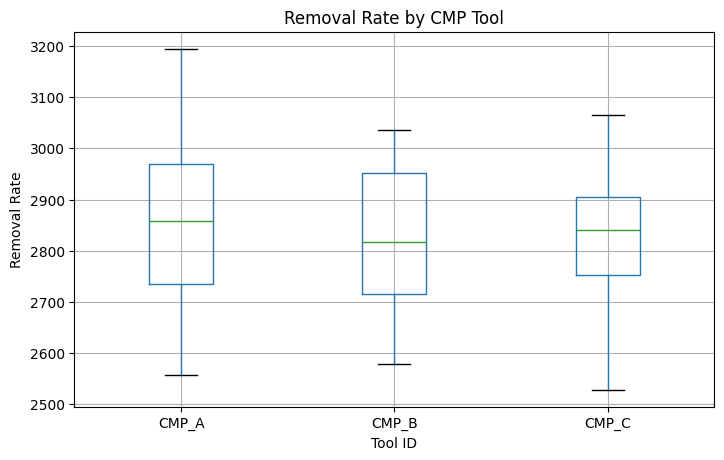

In [5]:
# CMP 설비별 Removal Rate 분포 비교
# 설비 간 공정 성능 차이가 있는지 시각적으로 확인

df.boxplot(
    column='RR_MEAN',
    by='TOOL_ID',
    figsize=(8, 5)
)

plt.xlabel('Tool ID')
plt.ylabel('Removal Rate')
plt.title('Removal Rate by CMP Tool')

# pandas가 자동으로 생성하는 상단 제목 제거
plt.suptitle('')

plt.show()

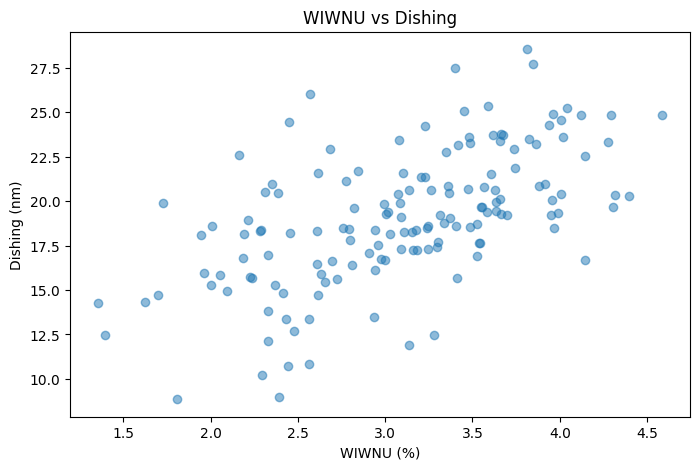

In [6]:
# WIWNU와 Dishing의 관계 확인
# 웨이퍼 내 균일도가 나빠질수록
# Dishing도 증가하는 경향이 있는지 확인

plt.figure(figsize=(8, 5))

plt.scatter(
    df['WIWNU'],
    df['DISHING_NM'],
    alpha=0.5
)

plt.xlabel('WIWNU (%)')
plt.ylabel('Dishing (nm)')
plt.title('WIWNU vs Dishing')

plt.show()

In [7]:
# CMP 핵심 파라미터 간 상관계수 계산
# +1에 가까움 → 함께 증가하는 경향
# -1에 가까움 → 하나가 증가할 때 다른 하나는 감소하는 경향
#  0에 가까움 → 뚜렷한 선형 관계가 약함

corr = df[
    [
        'RR_MEAN',
        'WIWNU',
        'DISHING_NM',
        'PAD_LIFE_WAFER'
    ]
].corr()

print("CMP 파라미터 상관행렬:")
print(corr.round(3))

CMP 파라미터 상관행렬:
                RR_MEAN  WIWNU  DISHING_NM  PAD_LIFE_WAFER
RR_MEAN           1.000 -0.554      -0.388          -0.673
WIWNU            -0.554  1.000       0.587           0.817
DISHING_NM       -0.388  0.587       1.000           0.505
PAD_LIFE_WAFER   -0.673  0.817       0.505           1.000


In [8]:
# 주요 관계의 상관계수를 따로 출력

corr_pad_rr = df['PAD_LIFE_WAFER'].corr(
    df['RR_MEAN']
)

corr_pad_wiwnu = df['PAD_LIFE_WAFER'].corr(
    df['WIWNU']
)

corr_wiwnu_dishing = df['WIWNU'].corr(
    df['DISHING_NM']
)

print(
    f"Pad Life vs Removal Rate: "
    f"{corr_pad_rr:.3f}"
)

print(
    f"Pad Life vs WIWNU: "
    f"{corr_pad_wiwnu:.3f}"
)

print(
    f"WIWNU vs Dishing: "
    f"{corr_wiwnu_dishing:.3f}"
)

Pad Life vs Removal Rate: -0.673
Pad Life vs WIWNU: 0.817
WIWNU vs Dishing: 0.587
